In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
faostat_df = pd.read_csv('FAOSTAT_data_en_11-19-2025.csv')
crop_df = pd.read_csv('Crop_recommendation.csv')

print("FAOSTAT head:")
print(faostat_df.head())
print("\nCrop dataset head:")
print(crop_df.head())

FAOSTAT head:
  Domain Code                        Domain  Area Code (M49)   Area  \
0         QCL  Crops and livestock products              356  India   
1         QCL  Crops and livestock products              356  India   
2         QCL  Crops and livestock products              356  India   
3         QCL  Crops and livestock products              356  India   
4         QCL  Crops and livestock products              356  India   

   Element Code         Element  Item Code (CPC)  \
0          5312  Area harvested           1654.0   
1          5412           Yield           1654.0   
2          5510      Production           1654.0   
3          5312  Area harvested           1654.0   
4          5412           Yield           1654.0   

                                                Item  Year Code  Year   Unit  \
0  Anise, badian, coriander, cumin, caraway, fenn...       2000  2000     ha   
1  Anise, badian, coriander, cumin, caraway, fenn...       2000  2000  kg/ha   
2  Ani

In [15]:
faostat_india = faostat_df[faostat_df['Area'] == 'India'].copy()

print("FAOSTAT India head:")
print(faostat_india.head())
print(f"FAOSTAT India shape: {faostat_india.shape}")

FAOSTAT India head:
  Domain Code                        Domain  Area Code (M49)   Area  \
0         QCL  Crops and livestock products              356  India   
1         QCL  Crops and livestock products              356  India   
2         QCL  Crops and livestock products              356  India   
3         QCL  Crops and livestock products              356  India   
4         QCL  Crops and livestock products              356  India   

   Element Code         Element  Item Code (CPC)  \
0          5312  Area harvested           1654.0   
1          5412           Yield           1654.0   
2          5510      Production           1654.0   
3          5312  Area harvested           1654.0   
4          5412           Yield           1654.0   

                                                Item  Year Code  Year   Unit  \
0  Anise, badian, coriander, cumin, caraway, fenn...       2000  2000     ha   
1  Anise, badian, coriander, cumin, caraway, fenn...       2000  2000  kg/ha   


In [16]:
print(f"Before explosion shape: {faostat_india.shape}")
print(faostat_india[['Item']].head())

faostat_india['crop'] = (
    faostat_india['Item']
    .str.split(',')
    .apply(lambda lst: [x.strip() for x in lst])
)

faostat_exploded = faostat_india.explode('crop').reset_index(drop=True)

print(f"\nAfter explosion shape: {faostat_exploded.shape}")
print(faostat_exploded[['Item','crop']].head())

Before explosion shape: (5940, 15)
                                                Item
0  Anise, badian, coriander, cumin, caraway, fenn...
1  Anise, badian, coriander, cumin, caraway, fenn...
2  Anise, badian, coriander, cumin, caraway, fenn...
3  Anise, badian, coriander, cumin, caraway, fenn...
4  Anise, badian, coriander, cumin, caraway, fenn...

After explosion shape: (9160, 16)
                                                Item       crop
0  Anise, badian, coriander, cumin, caraway, fenn...      Anise
1  Anise, badian, coriander, cumin, caraway, fenn...     badian
2  Anise, badian, coriander, cumin, caraway, fenn...  coriander
3  Anise, badian, coriander, cumin, caraway, fenn...      cumin
4  Anise, badian, coriander, cumin, caraway, fenn...    caraway


In [17]:
faostat_exploded = faostat_exploded.rename(columns={'Item': 'item'})
crop_df = crop_df.rename(columns={'label': 'crop'})

print("Crop columns after rename:", crop_df.columns.tolist())
print("FAOSTAT columns after rename:", faostat_exploded.columns.tolist())

Crop columns after rename: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'crop']
FAOSTAT columns after rename: ['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code', 'Element', 'Item Code (CPC)', 'item', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description', 'Note', 'crop']


In [19]:
label_to_fao = {
    "apple": "Apples", "banana": "Bananas", "chickpea": "Chick peas",
    "coconut": "Coconuts", "coffee": "Coffee", "cotton": "Seed cotton",
    "grapes": "Grapes", "jute": "Jute", "lentil": "Lentils",
    "maize": "Maize (corn)", "mango": "Mangoes", "mothbeans": "Beans",
    "muskmelon": "Cantaloupes and other melons", "orange": "Oranges",
    "papaya": "Papayas", "pigeonpeas": "Pigeon peas", "rice": "Rice",
    "watermelon": "Watermelons"
}

In [20]:
crop_df['FAO_name'] = crop_df['crop'].map(label_to_fao)
faostat_exploded['FAO_name'] = faostat_exploded['crop']

crop_mapped = crop_df[~crop_df['FAO_name'].isna()].copy()
merged = faostat_exploded.merge(
    crop_mapped, on='FAO_name', how='inner', suffixes=('_fao', '_ml')
)

print(f"Merged shape: {merged.shape}")
print(f"Unique ML crops after mapping: {merged['crop_ml'].nunique()}")
print(sorted(merged['crop_ml'].unique()))

Merged shape: (129600, 25)
Unique ML crops after mapping: 18
['apple', 'banana', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'lentil', 'maize', 'mango', 'mothbeans', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'rice', 'watermelon']


In [23]:
merged['crop'] = merged['crop_ml']


In [24]:
merged_prod = merged[merged['Element'] == 'Yield'].copy()
print(f"Yield records: {len(merged_prod)}")


Yield records: 43200


In [26]:
cols_keep = ['Element','Value','N','P','K','temperature','humidity','ph','rainfall','crop']
final_df = merged[cols_keep].copy()
final_df = final_df[final_df['Element'] == 'Yield'].copy()

In [27]:
final_df

,Element,Value,N,P,K,temperature,humidity,ph,rainfall,crop
100,Yield,4565.2,24,128,196,22.750888,90.694892,5.521467,110.431786,apple
101,Yield,4565.2,7,144,197,23.849401,94.348150,6.133221,114.051249,apple
102,Yield,4565.2,14,128,205,22.608010,94.589006,6.226290,116.039659,apple
103,Yield,4565.2,8,120,201,21.186674,91.134357,6.321152,122.233323,apple
104,Yield,4565.2,20,129,201,23.410447,91.699133,5.587906,116.077793,apple
...,...,...,...,...,...,...,...,...,...,...
129495,Yield,28777.8,97,12,47,25.287846,89.636679,6.765095,58.286977,watermelon
129496,Yield,28777.8,110,7,45,26.638386,84.695469,6.189214,48.324286,watermelon
129497,Yield,28777.8,96,18,50,25.331045,84.305338,6.904242,41.532187,watermelon
129498,Yield,28777.8,83,23,55,26.897502,83.892415,6.463271,43.971937,watermelon


In [28]:
numeric_cols = ['Value','N','P','K','temperature','humidity','ph','rainfall']
for col in numeric_cols:
    Q1 = final_df[col].quantile(0.25)
    Q3 = final_df[col].quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR
    final_df = final_df[(final_df[col] >= low) & (final_df[col] <= high)]

In [29]:
print("Unique crops:", sorted(final_df['crop'].unique()))
print("Number of unique crops:", final_df['crop'].nunique())
print(final_df['crop'].value_counts())
print("\nFinal dataset:")
print(final_df.head())

Unique crops: ['banana', 'chickpea', 'coconut', 'coffee', 'cotton', 'jute', 'lentil', 'maize', 'mango', 'mothbeans', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'rice', 'watermelon']
Number of unique crops: 16
crop
banana        2400
muskmelon     2400
coconut       2400
coffee        2400
jute          2400
lentil        2400
maize         2400
cotton        2400
watermelon    2400
rice          2352
mango         2256
pigeonpeas    2112
chickpea      2088
orange        1872
mothbeans     1296
papaya        1220
Name: count, dtype: int64

Final dataset:
     Element    Value    N   P   K  temperature   humidity        ph  \
7300   Yield  30098.6   91  94  46    29.367924  76.249001  6.149934   
7301   Yield  30098.6  105  95  50    27.333690  83.676752  5.849076   
7302   Yield  30098.6  108  92  53    27.400536  82.962213  6.276800   
7303   Yield  30098.6   86  76  54    29.315908  80.115857  5.926825   
7304   Yield  30098.6   80  77  49    26.054330  79.396545  5.519088   

   

In [31]:
final_df.to_csv('Clean_FAOSTAT_Crop_18crops.csv', index=False)

In [32]:
print("Null counts:")
print(final_df.isna().sum())
print(f"\nDuplicates: {final_df.duplicated().sum()}")
final_df = final_df.drop_duplicates().reset_index(drop=True)
print(f"Clean shape: {final_df.shape}")

Null counts:
Element        0
Value          0
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
crop           0
dtype: int64

Duplicates: 410
Clean shape: (34386, 10)


In [34]:
print(f"Final dataset shape: {final_df.shape}")
print("\nColumn info:")
print(final_df.info())
print("\nDataset description:")
print(final_df.describe())

Final dataset shape: (34386, 10)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34386 entries, 0 to 34385
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Element      34386 non-null  object 
 1   Value        34386 non-null  float64
 2   N            34386 non-null  int64  
 3   P            34386 non-null  int64  
 4   K            34386 non-null  int64  
 5   temperature  34386 non-null  float64
 6   humidity     34386 non-null  float64
 7   ph           34386 non-null  float64
 8   rainfall     34386 non-null  float64
 9   crop         34386 non-null  object 
dtypes: float64(5), int64(3), object(2)
memory usage: 2.6+ MB
None

Dataset description:
              Value             N             P             K   temperature  \
count  34386.000000  34386.000000  34386.000000  34386.000000  34386.000000   
mean    8811.236282     63.489036     43.774647     35.246932     25.754075   
std    11254.2

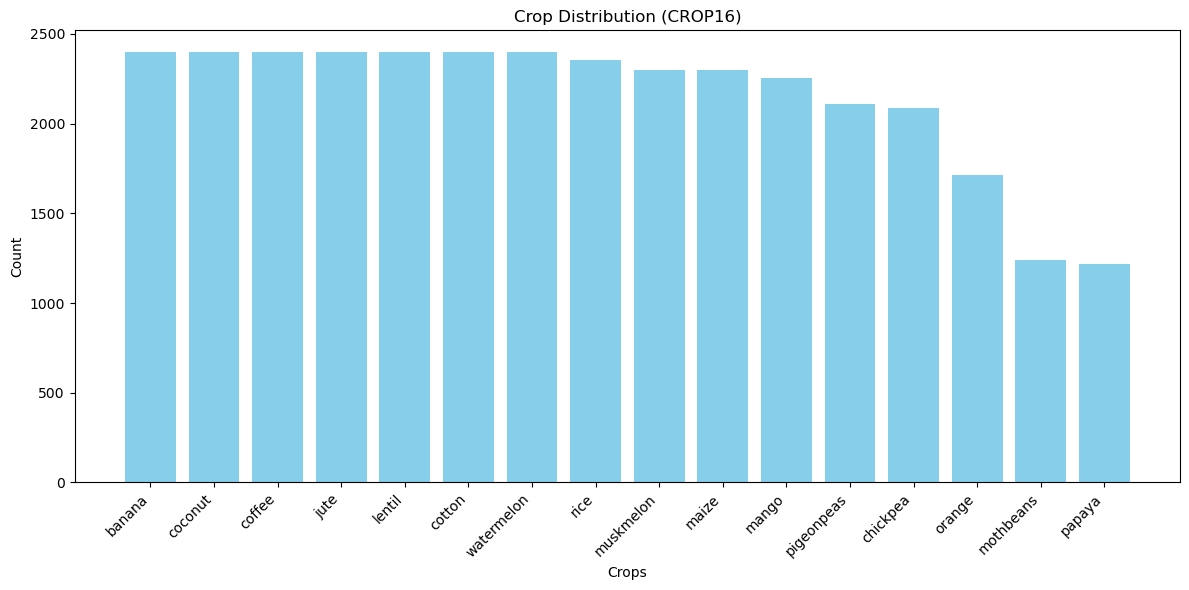

Most frequent: banana (2400)


In [35]:
plt.figure(figsize=(12,6))
crop_counts = final_df['crop'].value_counts()
plt.bar(crop_counts.index, crop_counts.values, color='skyblue')
plt.title('Crop Distribution (CROP16)')
plt.xlabel('Crops')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(f"Most frequent: {crop_counts.index[0]} ({crop_counts.iloc[0]})")

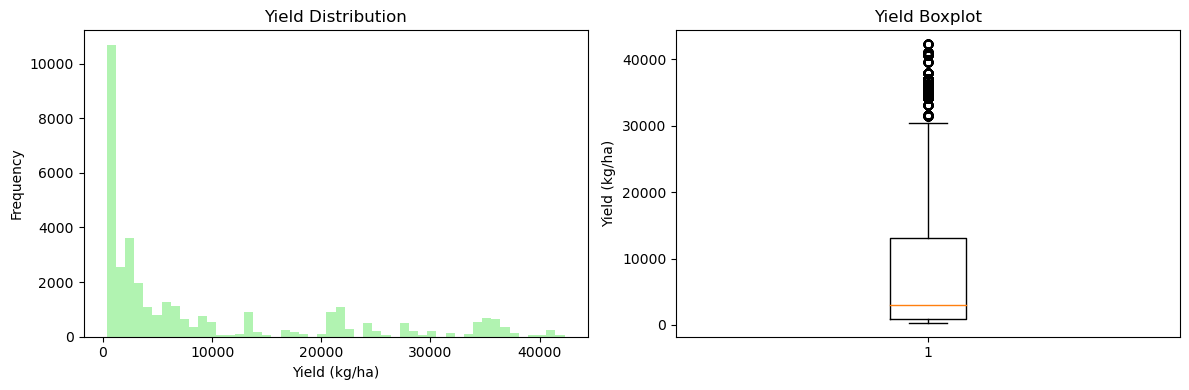

In [36]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(final_df['Value'], bins=50, color='lightgreen', alpha=0.7)
plt.title('Yield Distribution')
plt.xlabel('Yield (kg/ha)')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
plt.boxplot(final_df['Value'])
plt.title('Yield Boxplot')
plt.ylabel('Yield (kg/ha)')
plt.tight_layout()
plt.show()

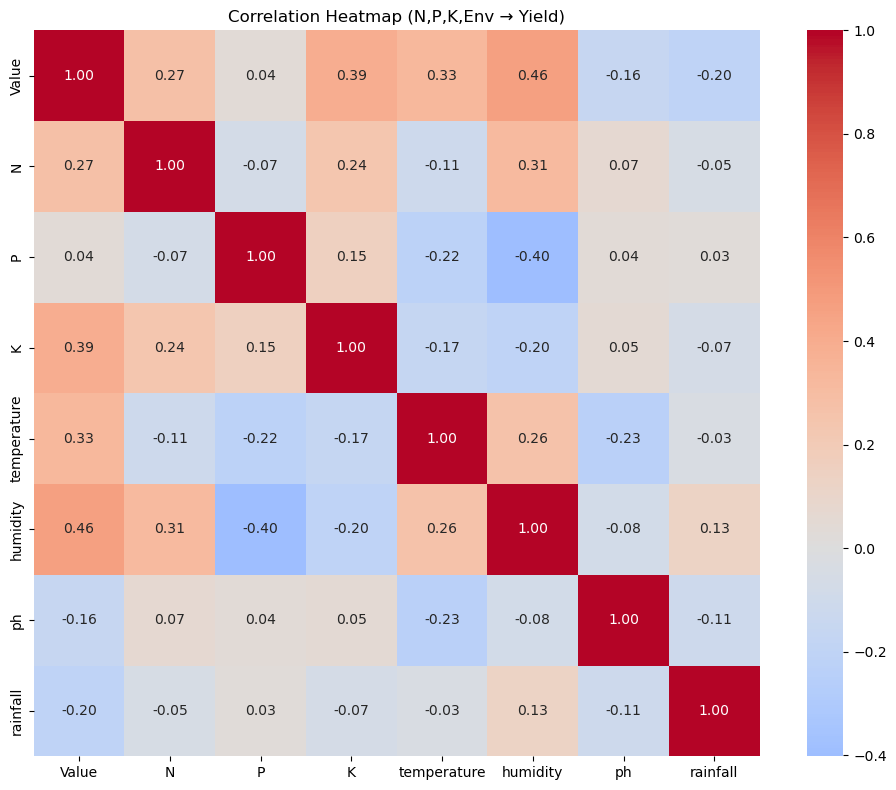

In [37]:
plt.figure(figsize=(10,8))
numeric_df = final_df[['Value','N','P','K','temperature','humidity','ph','rainfall']]
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f')
plt.title('Correlation Heatmap (N,P,K,Env → Yield)')
plt.tight_layout()
plt.show()

In [41]:
print("TRAINING RandomForest MODEL")
print("=" * 50)

# Prepare data
X = crop_df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = crop_df['crop']
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Train model
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

# Calculate accuracies
train_accuracy = clf.score(X_train, y_train)
test_accuracy = clf.score(X_test, y_test)

print(f" Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f" Test Accuracy:    {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f" Overfitting Gap:  {train_accuracy - test_accuracy:.4f}")

# Confusion Matrix Preview (top 5 predicted vs actual)
y_train_pred = clf.predict(X_train)

TRAINING RandomForest MODEL
 Training Accuracy: 1.0000 (100.00%)
 Test Accuracy:    0.9955 (99.55%)
 Overfitting Gap:  0.0045


In [42]:
CROP15 = ['banana','chickpea','coconut','coffee','cotton','jute','lentil','maize',
          'mango','mothbeans','muskmelon','orange','papaya','pigeonpeas','rice','watermelon']

user_input = {'N':90, 'P':40, 'K':40, 'temperature':25, 'humidity':80, 'ph':6.5, 'rainfall':120}

def predict_all_crops(params):
    input_df = pd.DataFrame([params])
    probs = clf.predict_proba(input_df)[0]
    crop_idx = [i for i,crop in enumerate(le.classes_) if crop in CROP15]
    return pd.DataFrame({
        'Crop': [le.classes_[i] for i in crop_idx],
        'Crop Probability': [round(probs[i]*100,2) for i in crop_idx]
    }).sort_values('Crop Probability', ascending=False).reset_index(drop=True)

probs_df = predict_all_crops(user_input)
print("Crop Probability")
print(probs_df)

Crop Probability
          Crop  Crop Probability
0         jute              55.0
1       banana              15.0
2       cotton               8.0
3        maize               6.0
4       coffee               5.0
5       papaya               4.0
6   watermelon               3.0
7         rice               2.0
8     chickpea               0.0
9      coconut               0.0
10      lentil               0.0
11       mango               0.0
12   mothbeans               0.0
13   muskmelon               0.0
14      orange               0.0
15  pigeonpeas               0.0


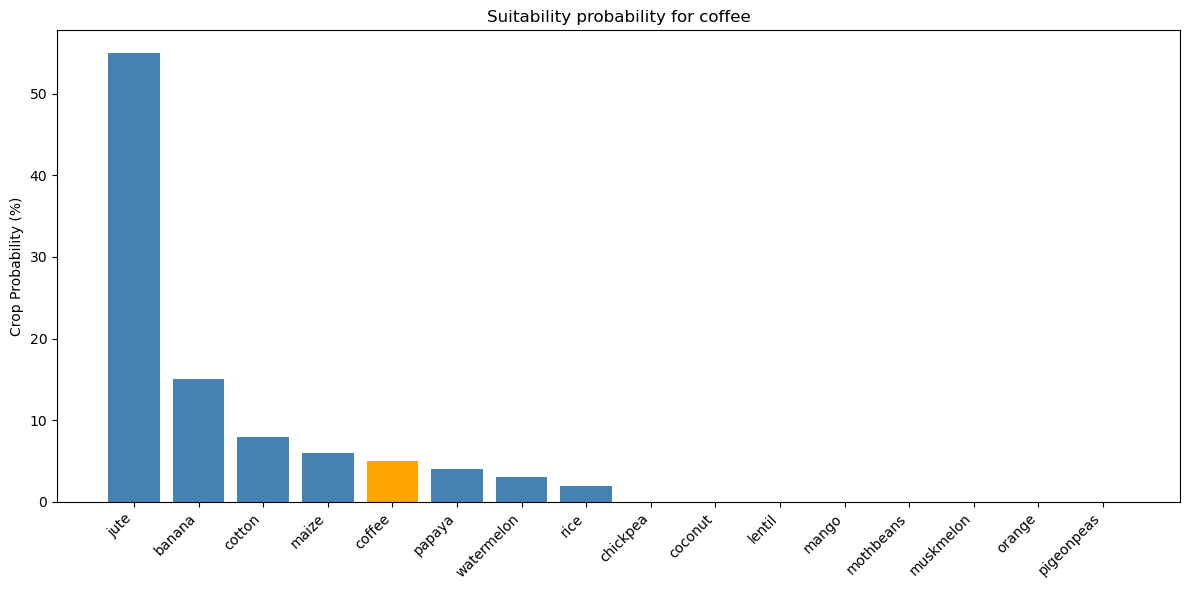

In [43]:
def plot_probabilities(df, requested_crop='coffee'):
    plt.figure(figsize=(12,6))
    colors = ['orange' if c==requested_crop else 'steelblue' for c in df['Crop']]
    plt.bar(df['Crop'], df['Crop Probability'], color=colors)
    plt.ylabel('Crop Probability (%)')
    plt.title(f'Suitability probability for {requested_crop}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_probabilities(probs_df, 'coffee')
